1 — Load All 12 Monthly Files

In [ ]:

from pathlib import Path
import pandas as pd

# Path to my folder
data_path = Path("bikeshare_trips")

# Get all CSV files in the folder
csv_files = sorted(data_path.glob("*.csv"))

print("Files found:")
for f in csv_files:
    print(f.name)

# Read and combine
dfs = []
for file in csv_files:
    df = pd.read_csv(file)
    dfs.append(df)

# Combine into one dataframe
all_trips = pd.concat(dfs, ignore_index=True)

print("\nTotal rows:", len(all_trips))
print("\nColumns:")
print(all_trips.columns)



Files found:
Bike share ridership 2022-01.csv
Bike share ridership 2022-02.csv
Bike share ridership 2022-03.csv
Bike share ridership 2022-04.csv
Bike share ridership 2022-05.csv
Bike share ridership 2022-06.csv
Bike share ridership 2022-07.csv
Bike share ridership 2022-08.csv
Bike share ridership 2022-09.csv
Bike share ridership 2022-10.csv
Bike share ridership 2022-11.csv
Bike share ridership 2022-12.csv

Total rows: 4620469

Columns:
Index(['Trip Id', 'Trip  Duration', 'Start Station Id', 'Start Time',
       'Start Station Name', 'End Station Id', 'End Time', 'End Station Name',
       'Bike Id', 'User Type'],
      dtype='object')


2 — Convert Date Column

In [10]:
all_trips["Start Time"] = pd.to_datetime(all_trips["Start Time"], errors="coerce")

# Drop bad rows
all_trips = all_trips.dropna(subset=["Start Time"])

3 — Create Daily Trip Counts (for your first visualization)

In [11]:
daily_trips = (
    all_trips
    .set_index("Start Time")
    .resample("D")
    .size()
    .rename("Trips")
    .reset_index()
)

print(daily_trips.head())

  Start Time  Trips
0 2022-01-01   2851
1 2022-01-02   1135
2 2022-01-03   2157
3 2022-01-04   3371
4 2022-01-05   2870


4 — Plot Trips Over Time

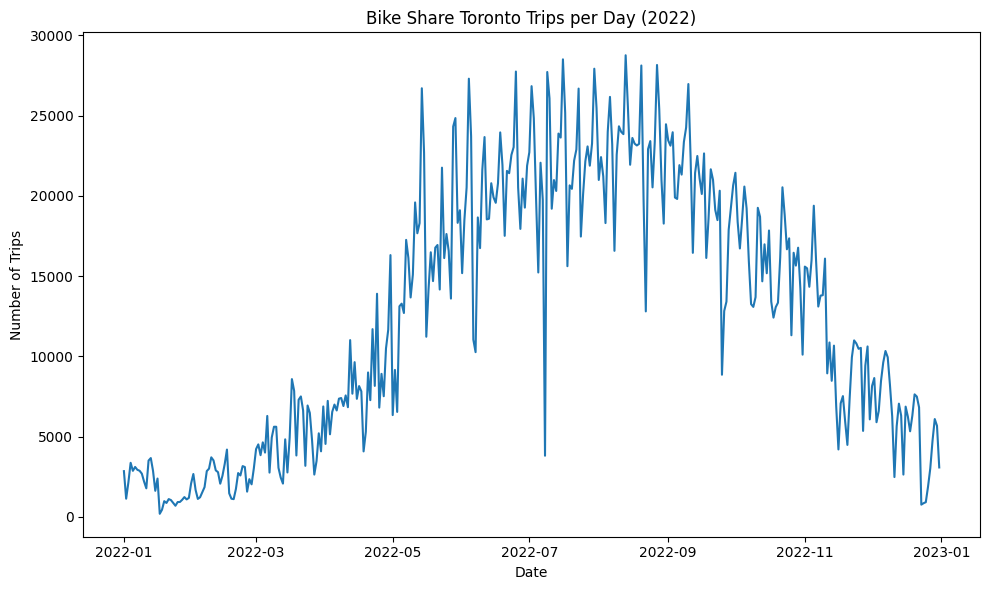

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.plot(daily_trips["Start Time"], daily_trips["Trips"])
plt.title("Bike Share Toronto Trips per Day (2022)")
plt.xlabel("Date")
plt.ylabel("Number of Trips")
plt.tight_layout()
plt.show()

Exporting the cleaned combined dataset to CSV to be used for visualization 2 (using Excel)

In [16]:
all_trips.to_csv("all_trips_2022.csv", index=False)